https://docs.fast.ai/tutorial.datablock.html#bounding-boxes

In [1]:
from fastai.vision.all import *

In [2]:
coco_source = untar_data(URLs.COCO_TINY)
images, lbl_bbox = get_annotations(coco_source/'train.json')
img2bbox = dict(zip(images, lbl_bbox))

In [3]:
coco = DataBlock(blocks=(ImageBlock, BBoxBlock, BBoxLblBlock),
                 get_items=get_image_files,
                 splitter=RandomSplitter(),
                 get_y=[lambda o: img2bbox[o.name][0], lambda o: img2bbox[o.name][1]], 
                 item_tfms=Resize(128),
                 batch_tfms=aug_transforms(),
                 n_inp=1)

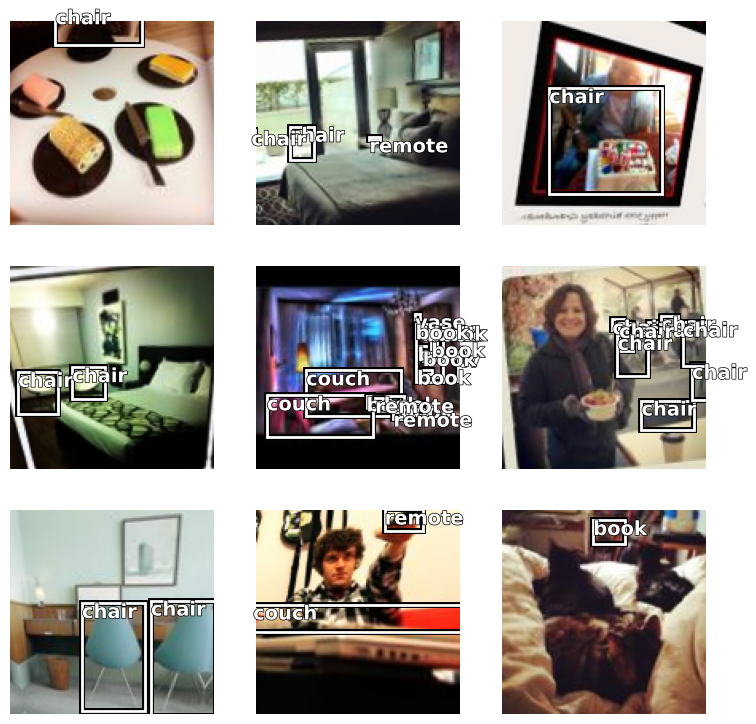

In [4]:
dls = coco.dataloaders(coco_source)
dls.show_batch(max_n=9)

In [5]:
dl = dls.show_batch(show=False)

In [6]:
dl[0][0].shape

torch.Size([3, 128, 128])

In [7]:
dls.vocab

['#na#', 'book', 'chair', 'couch', 'remote', 'tv', 'vase']

In [8]:
class OutConv(nn.Module):
    def __init__(self, k, nin, n_clas, bias):
        super().__init__()
        self.k = k
        self.oconv1 = nn.Conv2d(nin, n_clas*k, 3, padding=1)
        self.oconv2 = nn.Conv2d(nin, 4*k, 3, padding=1)
        self.oconv1.bias.data.zero_().add_(bias)
        
    def forward(self, x):
        return [flatten_conv(self.oconv1(x), self.k),
                flatten_conv(self.oconv2(x), self.k)]

In [9]:
class StdConv(nn.Module):
    def __init__(self, nin, nout, stride=2, drop=0.1):
        super().__init__()
        self.conv = nn.Conv2d(nin, nout, 3, stride=stride, padding=1)
        self.bn = nn.BatchNorm2d(nout)
        self.drop = nn.Dropout(drop)
        
    def forward(self, x): return self.drop(self.bn(F.relu(self.conv(x))))
        
def flatten_conv(x,k):
    bs,nf,gx,gy = x.size()
    x = x.permute(0,2,3,1).contiguous()
    return x.view(bs,-1,nf//k)

In [10]:
class SSD_Head(nn.Module):
    def __init__(self, k, n_clas, bias):
        super().__init__()
        self.drop = nn.Dropout(0.25)
        self.sconv0 = StdConv(512,256, stride=1)
#         self.sconv1 = StdConv(256,256)
        self.sconv2 = StdConv(256,256, stride=1)
        self.out = OutConv(k, 256, n_clas, bias)
        
    def forward(self, x):
        x = self.drop(F.relu(x))
        x = self.sconv0(x)
#         x = self.sconv1(x)
        x = self.sconv2(x)
        return self.out(x)

In [11]:
def intersect(box_a, box_b):
    max_xy = torch.min(box_a[:, None, 2:], box_b[None, :, 2:])
    min_xy = torch.max(box_a[:, None, :2], box_b[None, :, :2])
    inter = torch.clamp((max_xy - min_xy), min=0)
    return inter[:, :, 0] * inter[:, :, 1]

def box_sz(b): return ((b[:, 2]-b[:, 0]) * (b[:, 3]-b[:, 1]))

def jaccard(box_a, box_b):
    inter = intersect(box_a, box_b)
    union = box_sz(box_a).unsqueeze(1) + box_sz(box_b).unsqueeze(0) - inter
    return inter / union

In [12]:
def hw2corners(ctr, hw):
    return torch.cat([ctr - hw/2, ctr + hw/2], dim=1)

In [13]:
# def get_y(bbox,clas):
#     sz = 1 # since out co-ordinates are normalized  
#     bbox = bbox.view(-1,4)/sz
#     bb_keep = ((bbox[:,2]-bbox[:,0])>0).nonzero()[:,0]
#     # print(bbox[bb_keep].shape)
#     return bbox[bb_keep],clas[bb_keep]

## the method changes since this is coco dataset
def get_y(bbox, clas):
    bbox = bbox.view(-1,4).as_subclass(torch.Tensor)
    clas = clas.view(-1).as_subclass(torch.Tensor)

    mask = (bbox[:,2] > 0) & (bbox[:,3] > 0)  # for your [x,y,h,w] format
    # mask = (bbox[:,2]) * (bbox[:,3]) > 0
    return bbox[mask], clas[mask]

In [14]:
def actn_to_bb(actn, anchors):
    actn_bbs = torch.tanh(actn)
    actn_centers = (actn_bbs[:,:2]/2 * grid_sizes) + anchors[:,:2]
    actn_hw = (actn_bbs[:,2:]/2+1) * anchors[:,2:]
    return hw2corners(actn_centers, actn_hw)

def map_to_ground_truth(overlaps, print_it=False):
    prior_overlap, prior_idx = overlaps.max(1)
    if print_it: print(prior_overlap)
#     pdb.set_trace()
    gt_overlap, gt_idx = overlaps.max(0)
    gt_overlap[prior_idx] = 1.99
    for i,o in enumerate(prior_idx): gt_idx[o] = i
    return gt_overlap,gt_idx

# def ssd_1_loss(b_c,b_bb,bbox,clas,print_it=False):
#     # import pdb
#     # pdb.set_trace()
#     bbox,clas = get_y(bbox,clas)
#     a_ic = actn_to_bb(b_bb, anchors)
#     overlaps = jaccard(bbox.data, anchor_cnr.data)
#     gt_overlap,gt_idx = map_to_ground_truth(overlaps,print_it)
#     gt_clas = clas[gt_idx]
#     pos = gt_overlap > 0.4
#     pos_idx = torch.nonzero(pos)[:,0]
#     # gt_clas[~pos] = len(dls.vocab) - 1 # since vocab contains '#na' as well, also changed 1-pos -> ~pos
#     gt_clas[~pos] = 0 # change due to coco dataset
#     gt_bbox = bbox[gt_idx]
#     loc_loss = ((a_ic[pos_idx] - gt_bbox[pos_idx]).abs()).mean()
#     clas_loss  = loss_f(b_c, gt_clas)
#     return loc_loss, clas_loss

def ssd_1_loss(b_c, b_bb, bbox, clas, print_it=False):
    bbox, clas = get_y(bbox, clas)
    
    # handle images with no objects
    if bbox.numel() == 0:
        gt_clas = torch.zeros(b_c.shape[0], dtype=torch.long, device=b_c.device)
        clas_loss = loss_f(b_c, gt_clas)
        loc_loss = torch.tensor(0., device=b_c.device)
        return loc_loss, clas_loss
    
    a_ic = actn_to_bb(b_bb, anchors)
    overlaps = jaccard(bbox.data, anchor_cnr.data)
    gt_overlap, gt_idx = map_to_ground_truth(overlaps, print_it)
    gt_clas = clas[gt_idx]
    pos = gt_overlap > 0.4
    pos_idx = torch.nonzero(pos)[:, 0]
    gt_clas[~pos] = 0  # background = index 0
    gt_bbox = bbox[gt_idx]
    loc_loss = ((a_ic[pos_idx] - gt_bbox[pos_idx]).abs()).mean()
    clas_loss = loss_f(b_c, gt_clas)
    return loc_loss, clas_loss

def ssd_loss(pred, bbox, clas, print_it=False):
    # from pdb import set_trace
    # set_trace()
    lcs,lls = 0.,0.
    for b_c,b_bb,bbox,clas in zip(pred[0], pred[1], bbox, clas):
        loc_loss,clas_loss = ssd_1_loss(b_c,b_bb,bbox,clas,print_it)
        lls += loc_loss
        lcs += clas_loss
    if print_it: print(f'loc: {lls.data[0]}, clas: {lcs.data[0]}')
    return lls+lcs

In [15]:
# def detn_loss(inp, t1,t2):
#     print(inp[0].shape, inp[1].shape, '|', t1.shape, t2.shape)    # print(inp)

In [16]:
anc_grid = 4
k = 1

anc_offset = 1/(anc_grid*2)
anc_x = np.repeat(np.linspace(anc_offset, 1-anc_offset, anc_grid), anc_grid)
anc_y = np.tile(np.linspace(anc_offset, 1-anc_offset, anc_grid), anc_grid)

anc_ctrs = np.tile(np.stack([anc_x,anc_y], axis=1), (k,1))
anc_sizes = np.array([[1/anc_grid,1/anc_grid] for i in range(anc_grid*anc_grid)])
anchors = torch.tensor(np.concatenate([anc_ctrs, anc_sizes], axis=1), requires_grad=False, device='cuda', dtype=torch.float32)

In [17]:
grid_sizes = torch.tensor([1/anc_grid], requires_grad=False,  device='cuda').unsqueeze(1)

In [18]:
anchor_cnr = hw2corners(anchors[:,:2], anchors[:,2:])
anchor_cnr

tensor([[0.0000, 0.0000, 0.2500, 0.2500],
        [0.0000, 0.2500, 0.2500, 0.5000],
        [0.0000, 0.5000, 0.2500, 0.7500],
        [0.0000, 0.7500, 0.2500, 1.0000],
        [0.2500, 0.0000, 0.5000, 0.2500],
        [0.2500, 0.2500, 0.5000, 0.5000],
        [0.2500, 0.5000, 0.5000, 0.7500],
        [0.2500, 0.7500, 0.5000, 1.0000],
        [0.5000, 0.0000, 0.7500, 0.2500],
        [0.5000, 0.2500, 0.7500, 0.5000],
        [0.5000, 0.5000, 0.7500, 0.7500],
        [0.5000, 0.7500, 0.7500, 1.0000],
        [0.7500, 0.0000, 1.0000, 0.2500],
        [0.7500, 0.2500, 1.0000, 0.5000],
        [0.7500, 0.5000, 1.0000, 0.7500],
        [0.7500, 0.7500, 1.0000, 1.0000]], device='cuda:0')

In [19]:
# learn = vision_learner(dls, resnet34, loss_func=detn_loss, n_out=2)

In [20]:
n_clas = len(dls.vocab)
head = SSD_Head(k=1, n_clas=n_clas, bias=-3.)
learn = vision_learner(dls, resnet34, custom_head=head, loss_func=ssd_loss)

In [21]:
learn.loss_func

<function __main__.ssd_loss(pred, bbox, clas, print_it=False)>

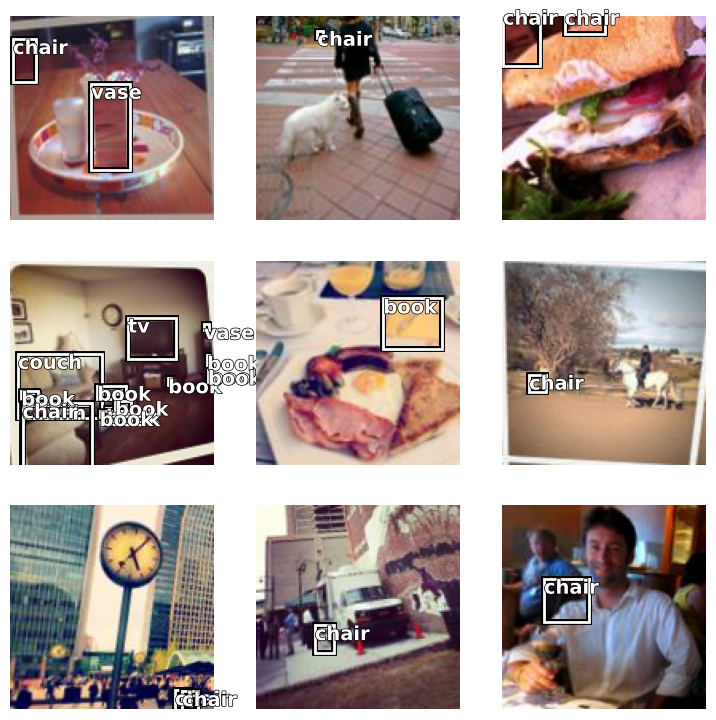

In [22]:
dls.show_batch()

In [23]:
def one_hot_embedding(labels, num_classes):
    return torch.eye(num_classes)[labels.data.cpu()]

class BCE_Loss(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes

    def forward(self, pred, targ):
        t = one_hot_embedding(targ, self.num_classes+1)
        t = t[:,:-1].contiguous().cuda()#.cpu()
        x = pred[:,:-1]
        w = self.get_weight(x,t)
        return F.binary_cross_entropy_with_logits(x, t, w, size_average=False)/self.num_classes
    
    def get_weight(self,x,t): return None

loss_f = BCE_Loss(len(dls.vocab)-1)

In [24]:
learn.loss_func??

Signature: learn.loss_func(pred, bbox, clas, print_it=False)
Docstring: <no docstring>
Source:   
def ssd_loss(pred, bbox, clas, print_it=False):
    # from pdb import set_trace
    # set_trace()
    lcs,lls = 0.,0.
    for b_c,b_bb,bbox,clas in zip(pred[0], pred[1], bbox, clas):
        loc_loss,clas_loss = ssd_1_loss(b_c,b_bb,bbox,clas,print_it)
        lls += loc_loss
        lcs += clas_loss
    if print_it: print(f'loc: {lls.data[0]}, clas: {lcs.data[0]}')
    return lls+lcs
File:      /tmp/ipykernel_2905/1421536607.py
Type:      function

In [26]:
learn.fine_tune(20)

epoch,train_loss,valid_loss,time
0,91.682449,65.803345,00:01


epoch,train_loss,valid_loss,time
0,95.276558,66.669586,00:01
1,85.492279,68.563049,00:01
2,83.376968,65.216560,00:01
3,81.755112,61.231464,00:01
4,80.970291,60.046257,00:01
5,79.498512,61.459515,00:01
6,78.703407,61.914574,00:01
7,76.112022,69.086304,00:01
8,75.001358,73.241707,00:01
9,72.807808,74.046989,00:01


In [25]:
get_annotations??


Signature: get_annotations(fname, prefix=None)
Source:   
def get_annotations(fname, prefix=None):
    "Open a COCO style json in `fname` and returns the lists of filenames (with maybe `prefix`) and labelled bboxes."
    annot_dict = json.load(open(fname))
    id2images, id2bboxes, id2cats = {}, collections.defaultdict(list), collections.defaultdict(list)
    classes = {o['id']:o['name'] for o in annot_dict['categories']}
    for o in annot_dict['annotations']:
        bb = o['bbox']
        id2bboxes[o['image_id']].append([bb[0],bb[1], bb[0]+bb[2], bb[1]+bb[3]])
        id2cats[o['image_id']].append(classes[o['category_id']])
    id2images = {o['id']:ifnone(prefix, '') + o['file_name'] for o in annot_dict['images'] if o['id'] in id2bboxes}
    ids = list(id2images.keys())
    return [id2images[k] for k in ids], [(id2bboxes[k], id2cats[k]) for k in ids]
File:      /usr/local/lib/python3.11/dist-packages/fastai/vision/core.py
Type:      function

In [ ]:
dls